In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
uniprotID_geneSymbol = pd.read_excel("D:/chh/2023workProject/prottalk/database/uniprotID_geneSymbol_geneID.xlsx")

In [2]:
matrixB = pd.read_csv("D:/chh/2023workProject/prottalk/code/differ analysis20230822/matrix.csv", index_col= 0)
drug_cell_drugs = pd.read_excel("D:/chh/2023workProject/prottalk/database/drug_cell_inhi24_IC50_MOA_combo_20231113-1549.xlsx" )
sampleInfoB = pd.read_csv("D:/chh/2023workProject/prottalk/database/iDrug_sample_final_info20231207_NY.csv")
sampleInfoB.iloc[1:2, ]

,Sample_ID,protein_plate,pert_id,pert_iname,pert_time,BioRep,NY
1,41rep,HCC1806,#72,Indocyanine,24,1,N


In [3]:
df_pre = pd.read_csv("//172.16.13.136/share/members/chenghonghan/PTV1/proof_check20260608/fig2/protein_gene.csv", index_col=0)
df_pre.head()

,geneSymbol
A0A024RBG1,NUDT4B
A0A1B0GUA7,TEX51
A0AV96,RBM47
A0AVT1,UBA6
A0FGR8,ESYT2


### Combine

In [ ]:
# cdk
# cluster1 = ["MCAT", "ASPH", "LRRC59", "GNB4", "NECTIN2", "PACSIN2", "DHRS4", "NOMO2", "AIDA", "UQCRB", "NQO1", "SAP30BP", "SPTBN2", "ZNF326", "ARHGAP29", "TMX1", 
# "GAR1", "APOC3", "UNC119B", "SURF2", "KRT1", "RHEB", "SNRPD1", "PRKAR2A", "SDHAF2", "IGFBP2", "RBM4B", "EIF2AK4", "MFGE8", "ZMPSTE24", "GRB2", "PIGU", 
# "MCU", "STAT6", "FTH1", "GOLGB1", "WRNIP1", "PSMD13", "BCAM", "CLCN7", "SDF2" ]
# cluster2 = ["RHOG", "DDX6", "FDXR", "UBAP2L", "YAP1", "PUS1", "CAST", "POLR2F", "CBR1", "ATG5", "UTP4", "S100A10", "SH3PXD2A", "TUBB4B", "QKI", "CAD",
# "PPP2R5D", "OGA", "MRPL3", "NRDC", "GTF3C4", "RFC3" ]

In [4]:
sb = "cdk inhibitor"
cluster1 = ["MCAT", "ASPH", "LRRC59", "GNB4", "NECTIN2", "PACSIN2", "DHRS4", "NOMO2", "AIDA", "UQCRB", "NQO1", "SAP30BP", "SPTBN2", "ZNF326", "ARHGAP29", "TMX1", 
"GAR1", "APOC3", "UNC119B", "SURF2", "KRT1", "RHEB", "SNRPD1", "PRKAR2A", "SDHAF2", "IGFBP2", "RBM4B", "EIF2AK4", "MFGE8", "ZMPSTE24", "GRB2", "PIGU", 
"MCU", "STAT6", "FTH1", "GOLGB1", "WRNIP1", "PSMD13", "BCAM", "CLCN7", "SDF2" ]
cluster2 = ["RHOG", "DDX6", "FDXR", "UBAP2L", "YAP1", "PUS1", "CAST", "POLR2F", "CBR1", "ATG5", "UTP4", "S100A10", "SH3PXD2A", "TUBB4B", "QKI", "CAD",
"PPP2R5D", "OGA", "MRPL3", "NRDC", "GTF3C4", "RFC3" ]

print(len(cluster1), len(cluster2))

dd  = drug_cell_drugs[ drug_cell_drugs["Subtype2"] == sb  ]["Pert_ID"].values

sample0 = list( set(sampleInfoB[ sampleInfoB["pert_time"] == 0 ]["Sample_ID"] ) & set(matrixB.index.values)  ) 

41 22


In [5]:
temp = sampleInfoB[ sampleInfoB["pert_id"].isin(dd) ]
temp = temp[temp["Sample_ID"].isin(list(matrixB.index.values))]
sample6_24_48_Y = temp[(temp["pert_time"] >0 )& (temp["NY"] =="Y")]["Sample_ID"].tolist()
sample6_24_48_N = temp[(temp["pert_time"] >0 )& (temp["NY"] !="Y")]["Sample_ID"].tolist()
print(len(sample6_24_48_Y), len(sample6_24_48_N))

cl = 1
pros = cluster1
uni = uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(pros)]["UniprotID"].unique()
uni = list(uni)
# print(uni)
temp_mat = matrixB.loc[sample0 + sample6_24_48_Y, uni ].dropna(how="all", axis=1).dropna(how="all", axis=0)#
temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
print('cluster{} {} {}samples {}cells:{}'.format(cl, 'Y', temp_mat.shape[0] , temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() ))

temp_mat = matrixB.loc[sample0 + sample6_24_48_N, uni ].dropna(how="all", axis=1).dropna(how="all", axis=0)#
temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
print('cluster{} {} {}samples {}cells:{}\n'.format(cl, 'N', temp_mat.shape[0] , temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() ))

cl = 2
pros = cluster2
uni = uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(pros)]["UniprotID"].unique()
uni = list(uni)
# print(uni)

temp_mat = matrixB.loc[sample0 + sample6_24_48_Y, uni ].dropna(how="all", axis=1).dropna(how="all", axis=0)
temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
print('cluster{} {} {}samples {}cells:{}'.format(cl, 'Y', temp_mat.shape[0]  , temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() ))

temp_mat = matrixB.loc[sample0 + sample6_24_48_N, uni ].dropna(how="all", axis=1).dropna(how="all", axis=0)
temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
print('cluster{} {} {}samples {}cells:{}'.format(cl, 'N', temp_mat.shape[0] , temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() ))

285 101
cluster1 Y 861samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']
cluster1 N 677samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']

cluster2 Y 861samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']
cluster2 N 677samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']


41 22


C:\Users\dell\AppData\Local\Temp\ipykernel_9036\325876597.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = df_pre.loc[proCur, ][0]
C:\Users\dell\AppData\Local\Temp\ipykernel_9036\325876597.py:91: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = df_pre.loc[proCur, ][0]


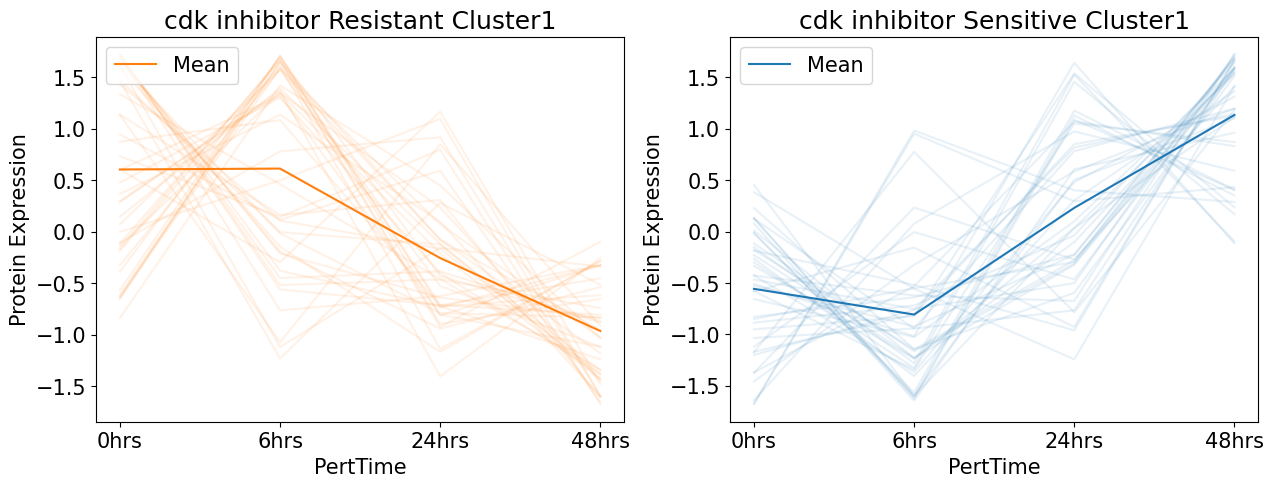

In [ ]:
sb = "cdk inhibitor"
cluster1 = ["MCAT", "ASPH", "LRRC59", "GNB4", "NECTIN2", "PACSIN2", "DHRS4", "NOMO2", "AIDA", "UQCRB", "NQO1", "SAP30BP", "SPTBN2", "ZNF326", "ARHGAP29", "TMX1", 
"GAR1", "APOC3", "UNC119B", "SURF2", "KRT1", "RHEB", "SNRPD1", "PRKAR2A", "SDHAF2", "IGFBP2", "RBM4B", "EIF2AK4", "MFGE8", "ZMPSTE24", "GRB2", "PIGU", 
"MCU", "STAT6", "FTH1", "GOLGB1", "WRNIP1", "PSMD13", "BCAM", "CLCN7", "SDF2" ]
cluster2 = ["RHOG", "DDX6", "FDXR", "UBAP2L", "YAP1", "PUS1", "CAST", "POLR2F", "CBR1", "ATG5", "UTP4", "S100A10", "SH3PXD2A", "TUBB4B", "QKI", "CAD",
"PPP2R5D", "OGA", "MRPL3", "NRDC", "GTF3C4", "RFC3" ]

print(len(cluster1), len(cluster2))

dd  = drug_cell_drugs[ drug_cell_drugs["Subtype2"] == sb  ]["Pert_ID"].values

temp = sampleInfoB[ sampleInfoB["pert_id"].isin(dd)]
sample0 = list( set(sampleInfoB[ sampleInfoB["pert_time"] == 0 ]["Sample_ID"] ) & set(matrixB.index.values)  ) 

cl = 1
if cl == 1:
    pros = cluster1
else:
    pros = cluster2
uni = uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(pros)]["UniprotID"].unique()
uni = list(uni)

temp = sampleInfoB[ sampleInfoB["pert_id"].isin(dd) ]
temp = temp[temp["Sample_ID"].isin(list(matrixB.index.values))]
sample6 = temp[(temp["pert_time"] == 6 )& (temp["NY"] !="Y")]["Sample_ID"]
sample24 = temp[(temp["pert_time"] == 24 )& (temp["NY"] !="Y")]["Sample_ID"]
sample48 = temp[(temp["pert_time"] == 48 )& (temp["NY"] !="Y")]["Sample_ID"]
# matrixB.loc[sample0 + sample6.tolist()+ sample24.tolist()+ sample48.tolist(), uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(cluster1+cluster2)]["UniprotID"].unique()].to_excel("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/ResistantSensitive_CombinePro/"+ sb +"_combine_20231215-1730_N.xlsx")

matrix0 = list(matrixB.loc[sample0, uni ].mean().values)
if len(sample0) == 0:
    matrix0  = [np.nan]*len(uni)
matrix6 = list(matrixB.loc[sample6, uni ].mean().values)
if len(sample6) == 0:
    matrix6  = [np.nan]*len(uni)
matrix24 = list(matrixB.loc[sample24, uni ].mean().values)
if len(sample24) == 0:
    matrix24  = [np.nan]*len(uni)
matrix48 = list(matrixB.loc[sample48, uni ].mean().values)
if len(sample0) == 0:
    matrix48  = [np.nan]*len(uni)

df1 = pd.DataFrame(np.asarray([matrix0, matrix6, matrix24, matrix48]), columns=uni)
# scaler = MinMaxScaler()
scaler = StandardScaler()
df1 = pd.DataFrame(scaler.fit_transform(df1), columns = uni)# 最大最小值标准化

sample6 = temp[(temp["pert_time"] == 6 ) & (temp["NY"] =="Y")]["Sample_ID"]
sample24 = temp[(temp["pert_time"] == 24 )& (temp["NY"] =="Y")]["Sample_ID"]
sample48 = temp[(temp["pert_time"] == 48 )& (temp["NY"] =="Y")]["Sample_ID"]

# matrixB.loc[sample0 + sample6.tolist()+ sample24.tolist()+ sample48.tolist(), uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(cluster1+cluster2)]["UniprotID"].unique()].to_excel("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/ResistantSensitive_CombinePro/"+ sb +"_combine_20231215-1730_Y.xlsx")

matrix0 = list(matrixB.loc[sample0, uni ].mean().values)
if len(sample0) == 0:
    matrix0  = [np.nan]*len(uni)
matrix6 = list(matrixB.loc[sample6, uni ].mean().values)
if len(sample6) == 0:
    matrix6  = [np.nan]*len(uni)
matrix24 = list(matrixB.loc[sample24, uni ].mean().values)
if len(sample24) == 0:
    matrix24  = [np.nan]*len(uni)
matrix48 = list(matrixB.loc[sample48, uni ].mean().values)
if len(sample0) == 0:
    matrix48  = [np.nan]*len(uni)

df2 = pd.DataFrame(np.asarray([matrix0, matrix6, matrix24, matrix48]), columns=uni)
df2 = pd.DataFrame(scaler.fit_transform(df2), columns = uni)
df = pd.concat([df1, df2])
# # df = pd.DataFrame(scaler.fit_transform(df ), columns=uni)

plt.figure(figsize = (9, 3))
plt.subplot(121)
plt.title(sb  + " Resistant" + " Cluster"+ str(cl) )
x = list(range(1, 5, 1))
for proCur in uni:
    l = df_pre.loc[proCur, ][0]
    y1 = list(df[proCur].values[:4])
    plt.plot(x, y1, linestyle='-' , c = '#ff7f0e',alpha = 0.1  ) # label= l,  , "Resistant"
plt.plot(x, df.iloc[ :4, :].mean(axis = 1).values , linestyle='-' , label= "Mean", c = '#ff7f0e'  ) # , "Resistant"
plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
plt.ylabel('Protein Expression')
plt.xlabel('PertTime')
# plt.title(pathway  )# 
plt.legend(loc  = "upper left")

plt.subplot(122)
plt.title(sb + " Sensitive"  + " Cluster"+str(cl))
x = list(range(1, 5, 1))
for proCur in uni:
    l = df_pre.loc[proCur, ][0]
    y1 = list(df[proCur].values[4: ])
    plt.plot(x, y1, linestyle='-' ,  c = '#1f77b4', alpha=0.1 ) #  marker = "o"  label= l,    "Sensitive" 
    # y2  = [ np.percentile(matrix0 , 75) , np.percentile(matrix6 , 75) , np.percentile(matrix24  , 75) , np.percentile(matrix48 , 75) ]
    # y3  =  [ np.percentile(matrix0 , 25) , np.percentile(matrix6 , 25) , np.percentile(matrix24  , 25) , np.percentile(matrix48 , 25) ]
    # plt.fill_between(x, y2, y3, alpha=0.1, facecolor = '#ff7f0e')   
plt.plot(x, df.iloc[ 4:, :].mean(axis = 1).values , linestyle='-' , label= "Mean", c = '#1f77b4'  )
plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
plt.ylabel('Protein Expression')
plt.xlabel('PertTime')
# plt.title(pathway  )# 
plt.legend(loc  = "upper left") # 显示label
# plt.savefig("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/"+ sb +"_combine_cluster" + str(cl)+"_20231215-1730.pdf", bbox_inches = 'tight')
plt.show()
# plt.clf()

C:\Users\dell\AppData\Local\Temp\ipykernel_9036\2761979788.py:63: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = df_pre.loc[proCur, ][0]
C:\Users\dell\AppData\Local\Temp\ipykernel_9036\2761979788.py:77: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = df_pre.loc[proCur, ][0]


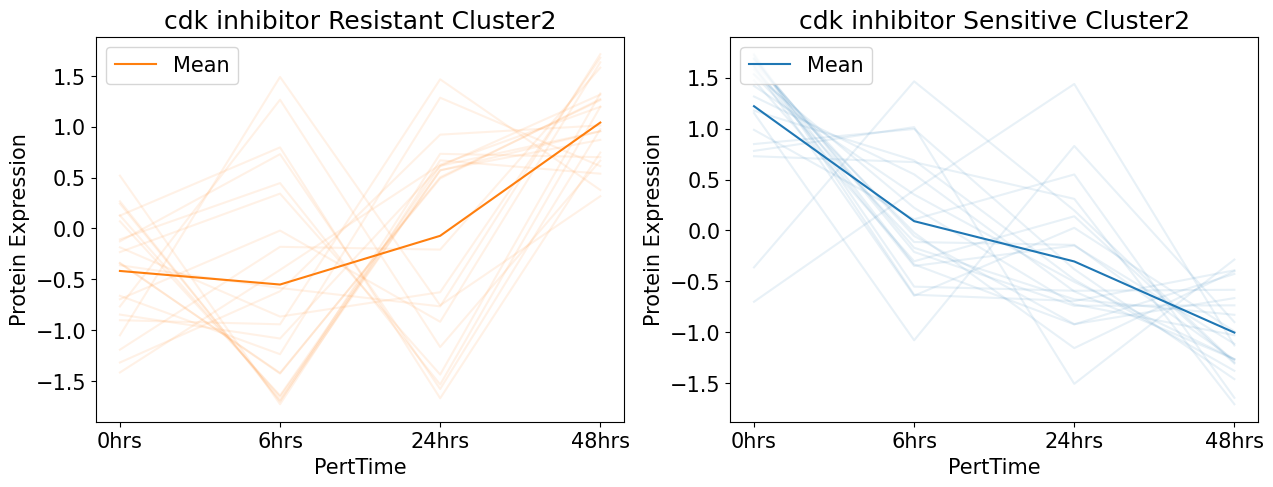

In [ ]:
cl = 2
if cl == 1:
    pros = cluster1
else:
    pros = cluster2
uni = uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(pros)]["UniprotID"].unique()
uni = list(uni)

temp = sampleInfoB[ sampleInfoB["pert_id"].isin(dd) ]
temp = temp[temp["Sample_ID"].isin(list(matrixB.index.values))]
sample6 = temp[(temp["pert_time"] == 6 )& (temp["NY"] !="Y")]["Sample_ID"]
sample24 = temp[(temp["pert_time"] == 24 )& (temp["NY"] !="Y")]["Sample_ID"]
sample48 = temp[(temp["pert_time"] == 48 )& (temp["NY"] !="Y")]["Sample_ID"]
# matrixB.loc[sample0 + sample6.tolist()+ sample24.tolist()+ sample48.tolist(), uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(cluster1+cluster2)]["UniprotID"].unique()].to_excel("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/ResistantSensitive_CombinePro/"+ sb +"_combine_20231215-1730_N.xlsx")

matrix0 = list(matrixB.loc[sample0, uni ].mean().values)
if len(sample0) == 0:
    matrix0  = [np.nan]*len(uni)
matrix6 = list(matrixB.loc[sample6, uni ].mean().values)
if len(sample6) == 0:
    matrix6  = [np.nan]*len(uni)
matrix24 = list(matrixB.loc[sample24, uni ].mean().values)
if len(sample24) == 0:
    matrix24  = [np.nan]*len(uni)
matrix48 = list(matrixB.loc[sample48, uni ].mean().values)
if len(sample0) == 0:
    matrix48  = [np.nan]*len(uni)

df1 = pd.DataFrame(np.asarray([matrix0, matrix6, matrix24, matrix48]), columns=uni)
# scaler = MinMaxScaler()
scaler = StandardScaler()
df1 = pd.DataFrame(scaler.fit_transform(df1), columns = uni)# 最大最小值标准化

sample6 = temp[(temp["pert_time"] == 6 ) & (temp["NY"] =="Y")]["Sample_ID"]
sample24 = temp[(temp["pert_time"] == 24 )& (temp["NY"] =="Y")]["Sample_ID"]
sample48 = temp[(temp["pert_time"] == 48 )& (temp["NY"] =="Y")]["Sample_ID"]

# matrixB.loc[sample0 + sample6.tolist()+ sample24.tolist()+ sample48.tolist(), uniprotID_geneSymbol[uniprotID_geneSymbol["GeneSymbol"].isin(cluster1+cluster2)]["UniprotID"].unique()].to_excel("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/ResistantSensitive_CombinePro/"+ sb +"_combine_20231215-1730_Y.xlsx")

matrix0 = list(matrixB.loc[sample0, uni ].mean().values)
if len(sample0) == 0:
    matrix0  = [np.nan]*len(uni)
matrix6 = list(matrixB.loc[sample6, uni ].mean().values)
if len(sample6) == 0:
    matrix6  = [np.nan]*len(uni)
matrix24 = list(matrixB.loc[sample24, uni ].mean().values)
if len(sample24) == 0:
    matrix24  = [np.nan]*len(uni)
matrix48 = list(matrixB.loc[sample48, uni ].mean().values)
if len(sample0) == 0:
    matrix48  = [np.nan]*len(uni)

df2 = pd.DataFrame(np.asarray([matrix0, matrix6, matrix24, matrix48]), columns=uni)
df2 = pd.DataFrame(scaler.fit_transform(df2), columns = uni)
df = pd.concat([df1, df2])
# # df = pd.DataFrame(scaler.fit_transform(df ), columns=uni)

plt.figure(figsize = (9, 3))
plt.subplot(121)
plt.title(sb  + " Resistant" + " Cluster"+ str(cl) )
x = list(range(1, 5, 1))
for proCur in uni:
    l = df_pre.loc[proCur, ][0]
    y1 = list(df[proCur].values[:4])
    plt.plot(x, y1, linestyle='-' , c = '#ff7f0e',alpha = 0.1  ) # label= l,  , "Resistant"
plt.plot(x, df.iloc[ :4, :].mean(axis = 1).values , linestyle='-' , label= "Mean", c = '#ff7f0e'  ) # , "Resistant"
plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
plt.ylabel('Protein Expression')
plt.xlabel('PertTime')
# plt.title(pathway  )# 
plt.legend(loc  = "upper left")

plt.subplot(122)
plt.title(sb + " Sensitive"  + " Cluster"+str(cl))
x = list(range(1, 5, 1))
for proCur in uni:
    l = df_pre.loc[proCur, ][0]
    y1 = list(df[proCur].values[4: ])
    plt.plot(x, y1, linestyle='-' ,  c = '#1f77b4', alpha=0.1 ) #  marker = "o"  label= l,    "Sensitive" 
    # y2  = [ np.percentile(matrix0 , 75) , np.percentile(matrix6 , 75) , np.percentile(matrix24  , 75) , np.percentile(matrix48 , 75) ]
    # y3  =  [ np.percentile(matrix0 , 25) , np.percentile(matrix6 , 25) , np.percentile(matrix24  , 25) , np.percentile(matrix48 , 25) ]
    # plt.fill_between(x, y2, y3, alpha=0.1, facecolor = '#ff7f0e')   
plt.plot(x, df.iloc[ 4:, :].mean(axis = 1).values , linestyle='-' , label= "Mean", c = '#1f77b4'  )
plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
plt.ylabel('Protein Expression')
plt.xlabel('PertTime')
# plt.title(pathway  )# 
plt.legend(loc  = "upper left") # 显示label

# D:\chh\2023workProject\prottalk\code\differ analysis\anova_two_ways_result\subtype_pertTime_anova_2ways_result\chemo_resistantSensitive_pathwayPro_plotline
# plt.savefig("D:/chh/2023workProject/prottalk/code/differ analysis/anova_two_ways_result/subtype_pertTime_anova_2ways_result/"+ sb +"_combine_cluster" + str(cl)+"_20231215-1730.pdf", bbox_inches = 'tight')
plt.show()
# plt.clf()